# Perceived text relevance from eye movements: short vs long documents

This notebook goes step by step from the **raw eye-tracking recordings** of the public gazeRE dataset to every
feature-based result of the paper

> A. Mohamed Selim, O. S. Bhatti, C. Conati, M. Barz, D. Sonntag.
> *A Comparative Analysis of Gaze-Based Representations for Perceived Text Relevance Estimation Across Short and
> Long Documents.* Scientific Reports.

**The question.** While people read a text to answer a question, can we tell from their eye movements alone
whether they find the text relevant? We study this on two kinds of text:
- **short documents** (g-REL): one paragraph that fits on the screen;
- **long documents** (GoogleNQ): several paragraphs that require scrolling.

We also ask whether a model trained on short documents still works on long ones (**transfer**).

**Sources.** Both sources are under GPL-3.0, and no data are copied into this repository.
- [gazeRE dataset](https://github.com/DFKI-Interactive-Machine-Learning/gazeRE-dataset) (Barz, Bhatti & Sonntag,
  2021): the recordings and ratings, which are downloaded in Section 2, and the official data loader and feature
  extractor.
- [GNN-Scanpath-Analysis-ICMI2024](https://github.com/DFKI-Interactive-Machine-Learning/GNN-Scanpath-Analysis-ICMI2024)
  (Mohamed Selim et al., ICMI '24): the generation of the heatmap and scanpath images used by the neural models,
  and their nested cross-validation protocol.

**How to use this notebook.** Run the cells from top to bottom; nothing needs to be edited. The first code cell
downloads the dataset if it is not there yet (about 100 MB). The whole notebook takes about 5 minutes on a laptop.
Every table and figure is also written to `results/`.

| Section | Content | In the paper |
|---|---|---|
| 1 | Setup | |
| 2 | Download and explore the gazeRE dataset | Methods: Dataset |
| 3 | From gaze samples to the 17 features | Methods, Table 1 |
| 4 | Evaluation protocol: folds, per-reader normalisation, metrics | Methods: Evaluation, Table S2 |
| 5 | Feature-based models within each corpus (nested selection) | Tables S3, S4 |
| 6 | The 3-second visit filter | Table S1 |
| 7 | Transfer from short to long documents | Tables S5, S6, S8 |
| 8 | What carries the transfer: features, distributions, PCA | Figures 7, 8, 9 |
| 9 | Generalisation to unseen documents | Figure 6, Table S7 |
| 10 | Neural models and statistical tests (optional inputs) | Results, Discussion |
| 11 | Summary | |

## 1. Setup

Install the requirements once (from the repository root):

```bash
python -m venv .venv && source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install -r requirements.txt
```

The cell below makes the package in `src/` importable without installing it and prints the software versions.
**scikit-learn must be 1.9.1.** Its `StratifiedGroupKFold` assigns participants to folds differently in other
versions, which changes the numbers slightly (see Section 4).

In [1]:
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt, sklearn, scipy
from IPython.display import display, Markdown
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 3)

from gaze_relevance import data, analyses as A, figures, __version__
from gaze_relevance.config import RESULTS, F17, HULL2, FEATURE_LABELS
from gaze_relevance.download import download_gazere
from gaze_relevance.evaluation import grel_subsets, nq_subsets, participant_folds

(RESULTS / "figures").mkdir(parents=True, exist_ok=True)
def save(df, name):
    # write a result table to results/<name>.csv and return it for display
    df.to_csv(RESULTS / f"{name}.csv", index=False)
    return df

print(f"gaze_relevance {__version__} | Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | "
      f"pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")
if sklearn.__version__ != "1.9.1":
    print("WARNING: install scikit-learn 1.9.1 (pip install -r requirements.txt) to obtain exactly the published folds.")

gaze_relevance 1.0.0 | Python 3.13.4 | scikit-learn 1.9.1 | pandas 3.0.6 | numpy 2.5.3 | scipy 1.18.1


## 2. The gazeRE dataset

**Study.** 24 participants (IDs `A01` ... `B13`) read 12 short documents from the g-REL corpus and 12 long
documents from Google Natural Questions (GoogleNQ). Each document came with a trigger question. After reading,
participants rated each text as relevant or irrelevant to the question:
- one rating per g-REL document;
- one rating per paragraph in GoogleNQ.

These ratings are the **perceived relevance**, which we predict. The corpora also provide the **system relevance**:
the corpus annotation of whether a text answers the question.

Gaze was recorded with a remote eye tracker on a 2560×1440 screen. The dataset is public under GPL-3.0:
<https://github.com/DFKI-Interactive-Machine-Learning/gazeRE-dataset>
(Barz, Bhatti & Sonntag, *Frontiers in Computer Science*, 2021).

### 2.1 Download

`download_gazere()` downloads the archive of a **fixed commit** of the dataset repository into `data/`, so every user
analyses exactly the same files. No git is needed, and nothing is downloaded if the data are already present.
To use a copy you already have, set the environment variable `GAZERE_DATA` to its folder before starting Jupyter,
or clone it next to this repository:

```bash
git clone https://github.com/DFKI-Interactive-Machine-Learning/gazeRE-dataset
```

`find_gazere_data()` then searches `$GAZERE_DATA`, `data/` and the folder next to the repository **recursively**.
It returns the folder that contains the participant folders.

In [2]:
try:
    root = data.find_gazere_data()                   # already downloaded or provided via GAZERE_DATA?
except FileNotFoundError:
    download_gazere()                                # -> data/gazeRE-dataset-<commit>/
    root = data.find_gazere_data()
print("participant folders found in: .../" + "/".join(root.parts[-2:]))
print("participants:", " ".join(sorted(p.name for p in root.iterdir() if p.is_dir())))

  20 MB


  40 MB


  60 MB


  80 MB


  unpacking ...


  done: gazeRE-dataset-9af27c6ed771fd8ac5619d020f688d70cd446d26
participant folders found in: .../gazeRE-dataset-9af27c6ed771fd8ac5619d020f688d70cd446d26/data
participants: A01 A03 A04 A06 A07 A08 A09 A10 A11 A12 A13 B01 B02 B03 B04 B05 B06 B07 B08 B09 B10 B11 B12 B13


### 2.2 What the files look like

Every participant has a folder with two sub-folders, `g-rel/` and `GoogleNQ/`. Each sub-folder holds:
- one CSV file per document, named `<reading order>_<stimulus>.csv`. The stimulus name of a g-REL document ends in
  its corpus label: `r` relevant, `t` topical (on topic but without the answer), `i` irrelevant;
- a `User_Rating` file with the participant's ratings, one line per document in reading order. GoogleNQ has one
  value per paragraph, separated by `|`.

The recordings are `|`-separated gaze samples. Their columns:

| column | meaning |
|---|---|
| `timestamp` | seconds since the document was opened |
| `gaze_x`, `gaze_y` | gaze position on the screen (px) |
| `gaze_y_abs` | vertical gaze position on the page, i.e. including scrolling (px) |
| `fixation_id` | running number of the fixation the sample belongs to (empty during saccades) |
| `scroll_y` | scroll position |
| `paragraph_id` | paragraph the gaze falls on (negative values: outside any paragraph) |

In [3]:
reader = "A01"
grel_files = sorted((root / reader / "g-rel").glob("*.csv"), key=lambda p: int(p.name.split("_")[0]))
nq_files = sorted((root / reader / "GoogleNQ").glob("*.csv"), key=lambda p: int(p.name.split("_")[0]))
print("g-REL files of", reader, ":", [p.name for p in grel_files[:4]], "...")
print("GoogleNQ files of", reader, ":", [p.name for p in nq_files[:3]], "...")
print("\ng-REL User_Rating (first 4 lines):", (root / reader / "g-rel" / "User_Rating").read_text().split()[:4])
print("GoogleNQ User_Rating (first 2 lines):", (root / reader / "GoogleNQ" / "User_Rating").read_text().split()[:2])
sample = pd.read_csv(grel_files[0], sep="|")
print(f"\n{grel_files[0].name}: {len(sample)} gaze samples over {sample.timestamp.max():.1f} s")
display(sample.head())

g-REL files of A01 : ['0_g-rel_q116-1_r.csv', '1_g-rel_q076-1_r.csv', '2_g-rel_q097-2_t.csv', '3_g-rel_q094-2_t.csv'] ...
GoogleNQ files of A01 : ['0_nq_7p_a1_Mzgy.csv', '1_nq_5p_a2_MTgz.csv', '2_nq_5p_a0_LTcw.csv'] ...

g-REL User_Rating (first 4 lines): ['True', 'False', 'False', 'False']
GoogleNQ User_Rating (first 2 lines): ['True|True|False|False|False|False|False', 'False|True|True|True|False']

0_g-rel_q116-1_r.csv: 3719 gaze samples over 44.8 s


,timestamp,gaze_x,gaze_y,gaze_y_abs,fixation_id,scroll_y,paragraph_id
0,0.000,2069.104,224.391,224.391,0.0,1.0,-2
1,0.012,2071.711,225.345,225.345,0.0,1.0,-2
2,0.024,2069.540,225.744,225.744,0.0,1.0,-2
3,0.036,2068.313,225.472,225.472,0.0,1.0,-2
4,0.048,2067.529,225.005,225.005,0.0,1.0,-2


### 2.3 Looking at one short and one long document

Below, every dot is a gaze sample, coloured from early (dark) to late (yellow). Every circle is a fixation, with
size proportional to its duration. Reading appears as rows of fixations that run left to right, one row per line
of text. The long document is drawn on the page (scrolling included), coloured by the paragraph the gaze falls on,
with the reader's rating for each paragraph.

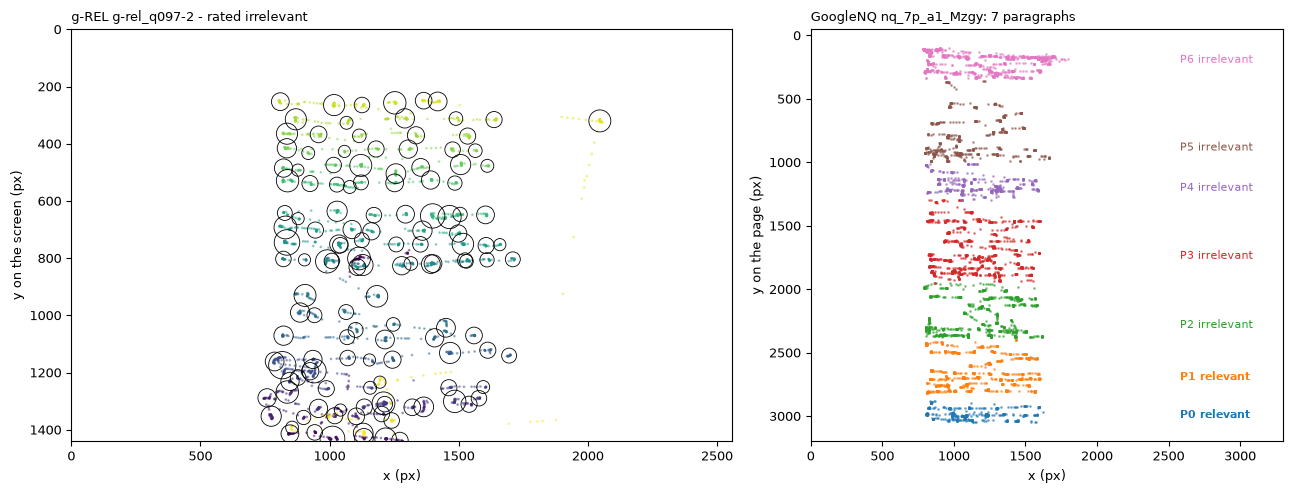

In [4]:
grel_study, nq_study = data.load_study(root)          # official gazeRE loader: {reader: {document: {...}}}
g_doc = next(iter(grel_study[reader]))
n_doc = next(iter(nq_study[reader]))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw=dict(width_ratios=[1.4, 1]))
s = grel_study[reader][g_doc]
figures.gaze_trial(s["dataframe"], f"g-REL {g_doc} - rated {'relevant' if s['perceived_relevance'][0] else 'irrelevant'}", ax=axes[0])
s = nq_study[reader][n_doc]
figures.paragraphs_of_document(s["dataframe"], s["perceived_relevance"], ax=axes[1])
axes[1].set_title(f"GoogleNQ {n_doc}: {s['num_paragraphs']} paragraphs", loc="left", fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "figures" / "example_trials.pdf", bbox_inches="tight")

## 3. From gaze samples to the 17 features

**Visits.** A visit is a continuous stretch of gaze on one paragraph; gaps shorter than 0.2 s are merged. For
each g-REL document and each GoogleNQ paragraph, the features are computed from the **longest visit**, and only
if that visit lasted **more than 3 seconds**. This follows the gazeRE paper; we analyse what the filter does in
Section 6.

**Features (Table 1 of the paper).** The extraction uses the official gazeRE `LongestVisitFeatureExtractor`, a copy
of which is included in `src/gaze_relevance/_gazere/`. The 17 features describe:
- fixations: count, durations;
- saccades: amplitudes, directions, velocities;
- the area covered by the gaze: bounding box and **convex hull**, i.e. the smallest convex polygon around all
  fixations.

Features 16 and 17 (convex hull area per time, fixations per convex hull area) describe how densely and slowly a
text is read. They will matter most in Section 7.

The first run extracts the features from all 24 × 24 recordings (about half a minute). The tables are then cached
in `.cache/`; delete that folder to extract again.

In [5]:
display(pd.DataFrame({"feature": F17, "description": [FEATURE_LABELS[f] for f in F17]}))
grel, nq = data.feature_tables(root)        # one row per g-REL trial / GoogleNQ paragraph with a visit > 3 s
visits = data.paragraph_visits(root)        # one row per paragraph, including those never visited for > 3 s
print(f"g-REL: {len(grel)} trials | GoogleNQ: {len(nq)} paragraphs with features, of {int((visits.corpus == 'nq').sum())} in total")
display(grel[["user_id", "document", "label", "system_label", "gREL_label"] + F17[:5]].head())

,feature,description
0,f_fixn_n,1. Number of fixations
1,f_fixn_dur_sum,2. Sum of fixation durations
2,f_fixn_dur_avg,3. Mean of fixation durations
3,f_fixn_dur_sd,4. SD of fixation durations
4,f_scan_distance_h,5. Sum of horizontal saccade amplitudes
5,f_scan_distance_v,6. Sum of vertical saccade amplitudes
6,f_scan_distance_euclid,7. Sum of saccade amplitudes
7,f_scan_hv_ratio,8. Horizontal/vertical amplitude ratio
8,f_avg_sacc_length,9. Average saccade amplitude
9,f_scan_speed_h,10. Horizontal saccade velocity


g-REL: 288 trials | GoogleNQ: 1504 paragraphs with features, of 1680 in total


,user_id,document,label,system_label,gREL_label,f_fixn_n,f_fixn_dur_sum,f_fixn_dur_avg,f_fixn_dur_sd,f_scan_distance_h
0,B10,g-rel_q128-1,True,True,r,81.0,17.479,0.216,0.115,16.585
1,B10,g-rel_q085-2,False,False,i,53.0,8.863,0.167,0.077,11.172
2,B10,g-rel_q075-1,False,False,i,155.0,37.116,0.239,0.140,28.872
3,B10,g-rel_q076-1,False,True,r,202.0,45.523,0.225,0.112,34.334
4,B10,g-rel_q097-2,False,False,t,106.0,21.861,0.206,0.106,21.134


**Subsets.** As in the paper, every corpus is analysed in subsets:
- **All**: every trial or paragraph.
- **Agree**: the perceived label equals the system label. For g-REL, topical documents are also excluded. These
  are the clearest cases.
- **Topical** (g-REL only): documents on the topic of the question but without the answer. These are the hardest
  cases.

The target `y` is the **perceived** relevance (1 = rated relevant).

In [6]:
rows = []
for corpus, subs in [("g-REL", grel_subsets(grel)), ("GoogleNQ", nq_subsets(nq))]:
    for k, d in subs.items():
        rows.append(dict(corpus=corpus, subset=k, samples=len(d), relevant=int(d.y.sum()), irrelevant=int((1 - d.y).sum()),
                         share_relevant=d.y.mean(), readers=d.user_id.nunique(), documents=d.document.nunique()))
display(save(pd.DataFrame(rows), "dataset_subsets"))

,corpus,subset,samples,relevant,irrelevant,share_relevant,readers,documents
0,g-REL,All,288,107,181,0.372,24,12
1,g-REL,Agree,181,86,95,0.475,24,8
2,g-REL,Topical,96,20,76,0.208,24,4
3,GoogleNQ,All,1504,433,1071,0.288,24,12
4,GoogleNQ,Agree,1277,242,1035,0.190,24,12


## 4. Evaluation protocol

### 4.1 Participant folds (Table S2)

Every model is tested on **readers it has not seen**. The outer folds are
`StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=256)`:
- grouped by participant, so all trials of a reader fall in the same fold;
- stratified by label, so every fold has a similar share of relevant texts.

Hyperparameters and algorithms are always chosen with an inner loop on the training readers only.

In [7]:
folds = save(A.fold_assignments(grel, nq), "table_S2_fold_assignments")
display(folds)

,subset,fold,participants,n_samples,n_relevant
0,g-REL All,1,"A03, A08, B07, B08, B10",60,21
1,g-REL All,2,"A07, A10, A11, B02, B11",60,21
2,g-REL All,3,"A06, A12, B01, B09, B12",60,23
3,g-REL All,4,"A09, B03, B05, B13",48,19
4,g-REL All,5,"A01, A04, A13, B04, B06",60,23
5,g-REL Agree,1,"A06, B01, B02, B05, B12",37,17
6,g-REL Agree,2,"A04, A08, A11, A12, B09",38,18
7,g-REL Agree,3,"A03, A09, A13, B04, B11",38,18
8,g-REL Agree,4,"A07, B06, B07, B08",30,15
9,g-REL Agree,5,"A01, A10, B03, B10, B13",38,18


### 4.2 Per-reader normalisation

People read differently. Some make many short fixations, some few long ones, and these differences are often
larger than the difference between relevant and irrelevant texts. The two corpora also differ, since a paragraph
is shorter than a full g-REL document. **Per-reader normalisation** expresses every feature relative to the same
reader's other texts in the same corpus: a z-score with the mean and standard deviation of that reader's trials.
A value of +1 then means "denser than this reader usually reads", whatever the reader's baseline or the corpus.

Two properties keep the procedure free of leakage:
- it uses **no labels**;
- it is computed once per corpus over **all** of a reader's trials, *before* label-defined subsets such as Agree
  are taken.

Min-Max scaling is always fitted on the training part of a fold. The figure shows
four readers: before normalisation the readers and the corpora sit at different levels (a); afterwards they are
comparable (b).

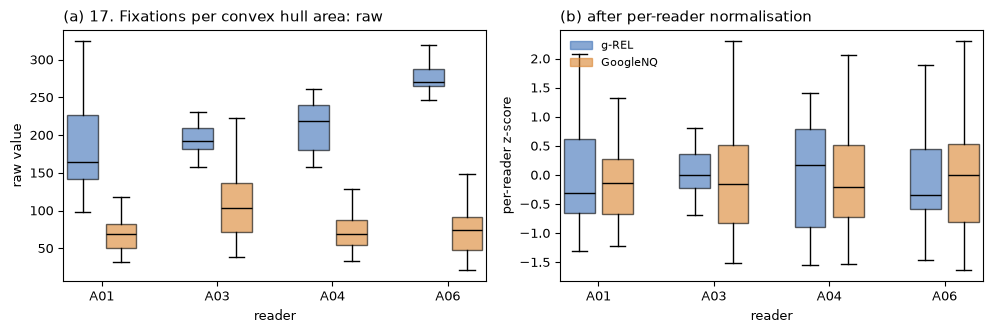

In [8]:
figures.normalisation_demo(grel, nq, path=RESULTS / "figures" / "per_reader_normalisation.pdf");

### 4.3 Metrics and uncertainty

- **Balanced accuracy (BA)** is the primary metric: the mean of the recall of both classes. 0.5 is chance level
  for any class ratio, which matters because only 29% of the GoogleNQ paragraphs are relevant.
- **F1, recall, precision**, with *relevant* as the positive class, computed from **one pooled confusion matrix**.
- **95% confidence interval**: bootstrap over **participants** (2000 resamples), because trials of the same reader
  are not independent.
- **Permutation test**: the labels are shuffled *within* each participant (500 permutations), which keeps every
  reader's share of relevant texts. The smallest attainable p-value is 1/501 ≈ 0.002.

The cell below runs automatic checks of the protocol:
- folds are participant-disjoint and cover every trial once;
- the normalisation does not change when the labels are shuffled;
- Agree uses the statistics of all trials;
- no held-out reader is ever in the training data of the transfer.

In [9]:
checks = save(A.leakage_checks(grel, nq), "protocol_checks")
display(checks)
assert checks.passed.all(), "a protocol check failed"

,check,passed
0,participant-disjoint folds covering all trials...,True
1,participant-disjoint folds covering all trials...,True
2,participant-disjoint folds covering all trials...,True
3,participant-disjoint folds covering all trials...,True
4,participant-disjoint folds covering all trials...,True
5,per-reader normalisation is label-free,True
6,Agree uses statistics of all g-REL trials of t...,True
7,transfer: held-out readers excluded from g-REL...,True


## 5. Feature-based models within each corpus (Tables S3, S4)

The classical baseline uses the twelve algorithms of the PyCaret pool that have a scikit-learn implementation,
all with default hyperparameters: LR, KNN, NB, DT, linear SVM, Ridge, RF, QDA, AdaBoost, GB, LDA and ET. The
algorithm is chosen **inside** a nested cross-validation:
1. for each outer fold, all twelve are compared in an inner participant-grouped 5-fold CV on the training readers;
2. the winner is refitted on all training readers and tested once on the held-out readers.

So the reported score never comes from the data used to pick the algorithm. The table shows the mean and SD over
the five outer folds and the algorithm selected in each fold.

**How to read it.** On g-REL the features clearly beat chance for All and Agree but not for Topical. On GoogleNQ
they stay close to chance.

In [10]:
nested, nested_folds = A.nested_selection(grel, nq)
save(nested, "tables_S3_S4_nested_selection"); save(nested_folds, "tables_S3_S4_nested_selection_folds")
display(nested)

,corpus,subset,BA_mean,BA_SD,selected_per_fold
0,g-REL,All,0.605,0.072,"LDA, KNN, Ridge, KNN, LDA"
1,g-REL,Agree,0.670,0.051,"ET, LDA, LDA, LDA, LDA"
2,g-REL,Topical,0.473,0.082,"LDA, NB, GB, DT, KNN"
3,GoogleNQ,All,0.564,0.031,"NB, NB, NB, NB, NB"
4,GoogleNQ,Agree,0.554,0.007,"NB, NB, NB, NB, NB"


## 6. The 3-second visit filter (Table S1)

The features require a visit longer than 3 s. On GoogleNQ, that filter removes far more paragraphs rated
irrelevant than relevant, because readers skip or glance at texts they find irrelevant. A skipped paragraph is
therefore itself a hint of irrelevance, and the filter hides it from the feature-based models.

The cells below show:
1. how many paragraphs of each class are removed;
2. the exclusion rate for thresholds from 0 to 5 s (**Table S1**);
3. a dwell-time-only model (log total dwell, log longest visit, number of visits; class-weighted logistic
   regression), trained on all 1680 paragraphs vs only those with a visit > 3 s.

**How to read it.** The ratio column says how many times more often an irrelevant paragraph is removed than a
relevant one. The dwell-time model does better when the short visits are kept.

In [11]:
counts, table_s1, dwell = A.visit_filter(visits)
save(counts, "visit_filter_counts"); save(table_s1, "table_S1_threshold_sensitivity"); save(dwell, "dwell_time_baseline")
display(counts); display(table_s1); display(dwell)

,subset,paragraphs,relevant,irrelevant,kept,removed_relevant,removed_irrelevant
0,All,1680,450,1230,1504,17,159
1,Agree,1438,248,1190,1277,6,155


,subset,threshold_s,kept,kept_relevant,kept_irrelevant,excluded_relevant_pct,excluded_irrelevant_pct,ratio
0,All,0.0,1677,449,1228,0.222,0.163,0.732
1,All,0.5,1669,448,1221,0.444,0.732,1.646
2,All,1.0,1650,446,1204,0.889,2.114,2.378
3,All,2.0,1589,442,1147,1.778,6.748,3.796
4,All,3.0,1504,433,1071,3.778,12.927,3.422
5,All,4.0,1404,415,989,7.778,19.593,2.519
6,All,5.0,1281,385,896,14.444,27.154,1.880
7,Agree,0.0,1437,248,1189,0.000,0.084,NaN
8,Agree,0.5,1429,247,1182,0.403,0.672,1.667
9,Agree,1.0,1412,247,1165,0.403,2.101,5.210


,subset,all_paragraphs_BA,visits_over_3s_BA,n_all,n_over_3s
0,All,0.596,0.579,1680,1504
1,Agree,0.593,0.563,1438,1277


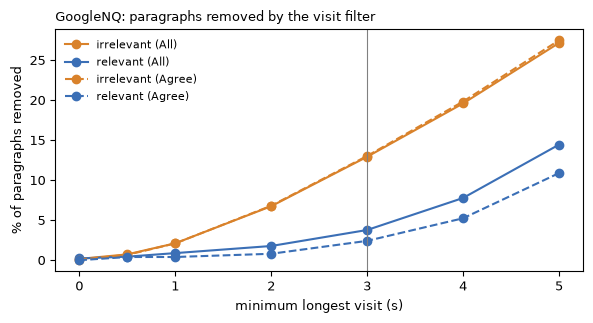

In [12]:
fig, ax = plt.subplots(figsize=(6, 3.3))
for sub, ls in [("All", "-"), ("Agree", "--")]:
    t = table_s1[table_s1.subset == sub]
    ax.plot(t.threshold_s, t.excluded_irrelevant_pct, ls, color="#d9822b", marker="o", label=f"irrelevant ({sub})")
    ax.plot(t.threshold_s, t.excluded_relevant_pct, ls, color="#3b6fb6", marker="o", label=f"relevant ({sub})")
ax.axvline(3, color="grey", lw=0.8); ax.set_xlabel("minimum longest visit (s)"); ax.set_ylabel("% of paragraphs removed")
ax.legend(frameon=False, fontsize=8); ax.set_title("GoogleNQ: paragraphs removed by the visit filter", loc="left", fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "figures" / "visit_filter.pdf", bbox_inches="tight")

## 7. Transfer from short (g-REL) to long (GoogleNQ) documents

**Main protocol: held-out readers.** The same 24 people read both corpora. Training on all g-REL readers and
testing on GoogleNQ would let a model recognise the *reader* rather than relevance. So, for each of the five
GoogleNQ participant folds, the model is trained on the g-REL trials of the **other** readers and tested on the
GoogleNQ paragraphs of the held-out readers.

**Selection on g-REL only.** The configuration is chosen without looking at GoogleNQ. The grid has
3 × 2 × 2 × 5 = 60 configurations:
- training subset: g-REL All, Agree, or without topical;
- features: all 17, or the 2 convex hull features;
- normalisation: Min-Max, or Min-Max + per-reader;
- model: LDA, LR, SVM, RF, NB.

Each configuration is scored by participant-grouped CV on g-REL, and the best one is evaluated **once** on
GoogleNQ (**Table S6**). The GoogleNQ columns of the grid are shown for transparency only and are not used for
selection.

In [13]:
grid = save(A.transfer_grid(grel, nq), "table_S6_transfer_grid")
display(grid.sort_values("grel_cv_BA", ascending=False).head(10))
rho = grid[["grel_cv_BA", "transfer_BA_All"]].corr("spearman").iloc[0, 1]
print(f"Spearman correlation between g-REL CV score and transfer BA (All) over the 60 configurations: {rho:.2f}")

,source,features,normalisation,model,grel_cv_BA,transfer_BA_All,transfer_BA_Agree
27,g-REL Agree,17 features,Min-Max + per-reader,SVM,0.737,0.580,0.580
29,g-REL Agree,17 features,Min-Max + per-reader,NB,0.732,0.591,0.582
36,g-REL Agree,2 convex hull features,Min-Max + per-reader,LR,0.725,0.617,0.631
35,g-REL Agree,2 convex hull features,Min-Max + per-reader,LDA,0.721,0.609,0.623
37,g-REL Agree,2 convex hull features,Min-Max + per-reader,SVM,0.716,0.607,0.626
28,g-REL Agree,17 features,Min-Max + per-reader,RF,0.714,0.595,0.602
45,g-REL without topical,17 features,Min-Max + per-reader,LDA,0.712,0.560,0.552
39,g-REL Agree,2 convex hull features,Min-Max + per-reader,NB,0.706,0.610,0.616
25,g-REL Agree,17 features,Min-Max + per-reader,LDA,0.705,0.558,0.571
26,g-REL Agree,17 features,Min-Max + per-reader,LR,0.700,0.591,0.589


Spearman correlation between g-REL CV score and transfer BA (All) over the 60 configurations: 0.55


**Table S5** reports four configurations:
1. the configuration **selected on g-REL**;
2. the **baseline**: LDA trained on g-REL All with Min-Max scaling only, i.e. without per-reader normalisation;
3. a **hypothesis-driven** LDA on the two convex hull features, with the selected training subset and
   normalisation. Prior work identified these features as relevance indicators; this row is reported independently
   of the selection;
4. the selected configuration with the **same readers** in training and test, which shows how much reader
   identity contributes.

**How to read it.** `CI_low` and `CI_high` are the participant-bootstrap 95% interval. `perm_p` is the
permutation test. `readers_above_chance` counts readers whose own BA exceeds 0.5. The confusion matrices below the
table show the trade-off: the revised models find most relevant paragraphs (high recall) at the cost of many
false alarms (low precision).

Selected on g-REL only: {'source': 'g-REL Agree', 'features': '17 features', 'normalisation': 'Min-Max + per-reader', 'model': 'SVM'} (g-REL CV BA 0.737)


,configuration,protocol,target,BA,CI_low,CI_high,perm_p,F1,recall,precision,TN,FP,FN,TP,readers_above_chance
0,selected on g-REL,held-out readers,GoogleNQ All,0.580,0.554,0.606,0.002,0.463,0.714,0.343,478,593,124,309,21/24
1,selected on g-REL,held-out readers,GoogleNQ Agree,0.580,0.562,0.600,0.002,0.350,0.723,0.231,453,582,67,175,22/24
2,"baseline (LDA, g-REL All, Min-Max)",held-out readers,GoogleNQ All,0.517,0.489,0.544,0.096,0.338,0.374,0.308,707,364,271,162,13/24
3,"baseline (LDA, g-REL All, Min-Max)",held-out readers,GoogleNQ Agree,0.517,0.486,0.546,0.066,0.262,0.364,0.205,693,342,154,88,15/24
4,convex hull LDA (hypothesis-driven),held-out readers,GoogleNQ All,0.609,0.581,0.639,0.002,0.485,0.704,0.370,551,520,128,305,22/24
5,convex hull LDA (hypothesis-driven),held-out readers,GoogleNQ Agree,0.623,0.600,0.647,0.002,0.384,0.736,0.260,528,507,64,178,24/24
6,"selected on g-REL (same readers, for comparison)",same readers,GoogleNQ All,0.582,0.556,0.608,0.002,0.465,0.723,0.343,472,599,120,313,20/24
7,"selected on g-REL (same readers, for comparison)",same readers,GoogleNQ Agree,0.595,0.573,0.616,0.002,0.361,0.744,0.239,461,574,62,180,22/24


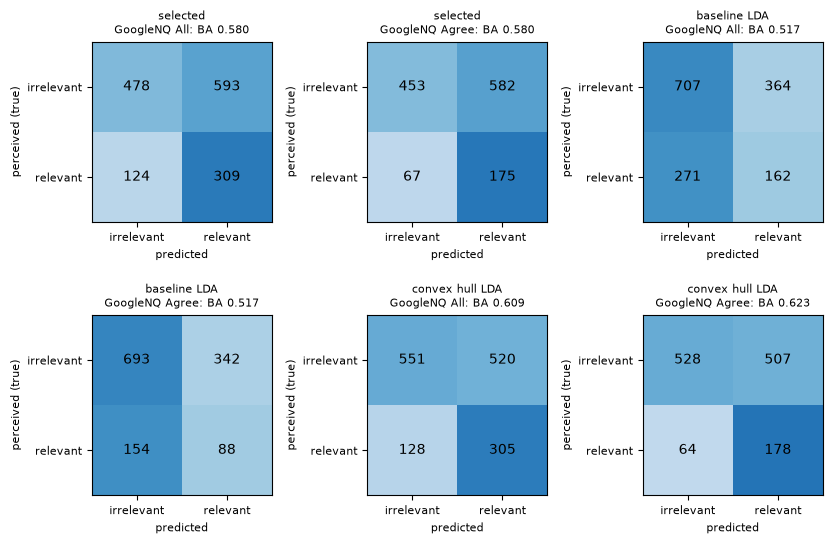

In [14]:
best, table_s5, transfer_preds = A.selected_transfer(grel, nq, grid)
print("Selected on g-REL only:", dict(best[["source", "features", "normalisation", "model"]]), f"(g-REL CV BA {best.grel_cv_BA:.3f})")
save(table_s5, "table_S5_transfer")
display(table_s5[["configuration", "protocol", "target", "BA", "CI_low", "CI_high", "perm_p", "F1", "recall", "precision",
                  "TN", "FP", "FN", "TP", "readers_above_chance"]])
short = {"selected on g-REL": "selected", "baseline (LDA, g-REL All, Min-Max)": "baseline LDA",
         "convex hull LDA (hypothesis-driven)": "convex hull LDA"}
cm = table_s5[table_s5.protocol == "held-out readers"].assign(short=lambda t: t.configuration.map(short))
figures.confusion_matrices(cm, RESULTS / "figures" / "transfer_confusion_matrices.pdf");

### 7.1 Transfer vs models trained on GoogleNQ itself

Is the transfer as good as simply training on long documents? The within-GoogleNQ reference is a class-weighted
RBF-SVM on the per-reader normalised 17 features, evaluated on the same participant folds. The two are compared
**per reader**, using the 24 readers as paired units and the Wilcoxon signed-rank test.

**How to read it.** A large p-value means no detectable difference: the transfer is comparable to, but not better
than, training on GoogleNQ.

In [15]:
within = A.within_googlenq(nq)
hull_preds = transfer_preds["convex hull LDA (hypothesis-driven)"]
selected_preds = transfer_preds["selected on g-REL"]
vs_within = pd.concat([A.transfer_vs_within(hull_preds, within).assign(transfer="convex hull LDA"),
                       A.transfer_vs_within(selected_preds, within).assign(transfer="selected configuration")])
display(save(vs_within, "transfer_vs_within_googlenq"))

,target,transfer_BA,within_BA,readers_transfer_better,readers_within_better,readers_equal,mean_reader_diff,wilcoxon_p,transfer
0,GoogleNQ All,0.609,0.624,13,11,0,-0.016,0.264,convex hull LDA
1,GoogleNQ Agree,0.623,0.615,10,14,0,0.006,0.855,convex hull LDA
0,GoogleNQ All,0.580,0.624,6,18,0,-0.045,0.005,selected configuration
1,GoogleNQ Agree,0.580,0.615,6,17,1,-0.033,0.031,selected configuration


### 7.2 Does the position of the paragraph matter? (Table S8)

Readers may form a first judgement at the beginning of a document and read differently afterwards (Li et al.). If
the transferred signal depended on this, the first paragraphs would be classified differently from the later ones.
The table splits the convex hull LDA transfer into the first two, the next two and the remaining paragraphs of
each document.

**How to read it.** The confidence intervals overlap, so there is no clear dependence on position.

In [16]:
positions = save(A.transfer_by_position(hull_preds), "table_S8_positions")
display(positions[["target", "position", "n", "BA", "CI_low", "CI_high", "recall", "precision"]])

,target,position,n,BA,CI_low,CI_high,recall,precision
0,GoogleNQ All,first two paragraphs,536,0.602,0.557,0.647,0.746,0.421
1,GoogleNQ All,next two paragraphs,527,0.590,0.552,0.627,0.735,0.307
2,GoogleNQ All,remaining paragraphs,441,0.631,0.590,0.673,0.603,0.387
3,GoogleNQ Agree,first two paragraphs,415,0.650,0.602,0.697,0.850,0.270
4,GoogleNQ Agree,next two paragraphs,467,0.582,0.542,0.621,0.716,0.214
5,GoogleNQ Agree,remaining paragraphs,395,0.646,0.599,0.691,0.642,0.321


## 8. What carries the transfer? (Figures 7, 8, 9)

These analyses are **exploratory**.

**Figure 7.** (a) **Permutation importance** of the selected transfer model, measured *on GoogleNQ* with held-out
readers: how much the BA drops when one feature is shuffled. (b) **SHAP values** of the same model, from a
KernelExplainer on 100 GoogleNQ paragraphs. Each dot is a paragraph, coloured by the feature value; dots to the
right push the model towards "relevant".

,feature,BA_drop,BA_drop_SD_folds,label
0,f_fixns_per_hull_area,2.049e-02,0.022,17. Fixations per convex hull area
1,f_hull_area_per_time,1.291e-02,0.018,16. Convex hull area per time
2,f_scan_hv_ratio,5.463e-03,0.004,8. Horizontal/vertical amplitude ratio
3,f_scan_speed_h,3.026e-03,0.005,10. Horizontal saccade velocity
4,f_avg_sacc_length,1.438e-03,0.014,9. Average saccade amplitude
5,f_scan_speed,-1.164e-04,0.006,12. Saccade velocity


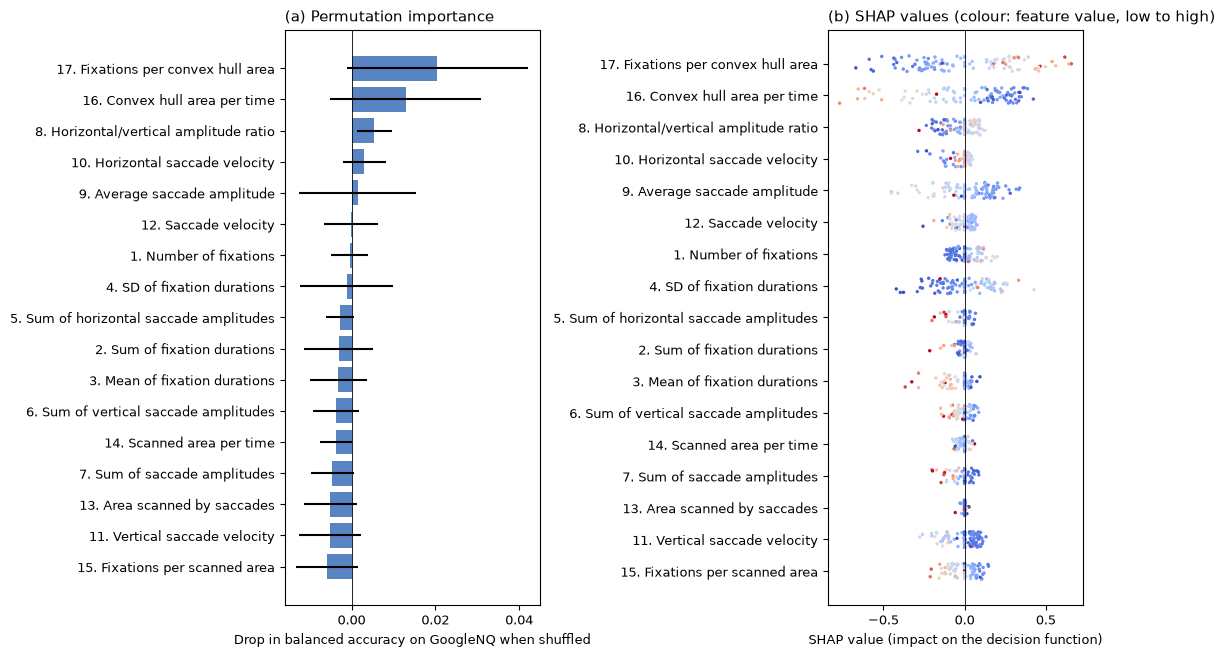

In [17]:
imp, shap_df = A.transfer_importance(grel, nq, best.source, best.features, best.normalisation, best.model)
save(imp.assign(label=imp.feature.map(FEATURE_LABELS)), "figure7_permutation_importance")
if shap_df is not None:
    save(shap_df, "figure7_shap_values")
display(imp.assign(label=imp.feature.map(FEATURE_LABELS)).head(6))
figures.feature_analysis(imp, shap_df, RESULTS / "figures" / "figure7_feature_analysis.pdf");

**Figure 8.** Distributions of the two convex hull features and the number of fixations, per corpus and class.
- **Top**: raw values. The corpora are far apart, simply because a paragraph is shorter than a document.
- **Bottom**: after per-reader normalisation. The corpora overlap, and relevant texts (solid lines) are read
  more densely than irrelevant ones (dashed lines) in *both* corpora.

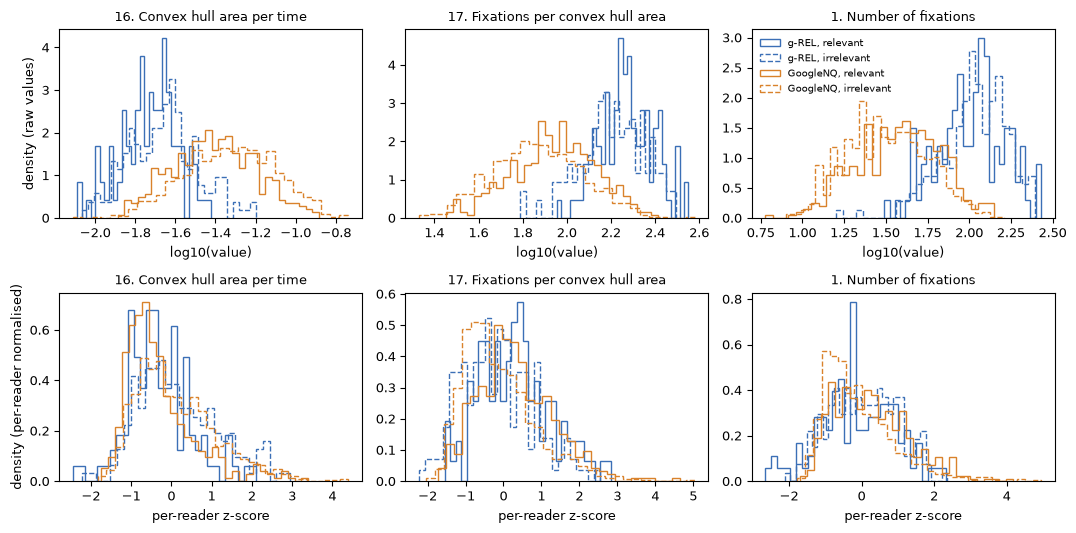

In [18]:
figures.distributions(grel, nq, path=RESULTS / "figures" / "figure8_distributions.pdf");

**Figure 9.** A two-component PCA of the 17 features of both corpora. The dashed line is the boundary of a
logistic regression fitted to separate the corpora on the two components; its balanced accuracy measures how
distinct the corpora are.
- With Min-Max normalisation the corpora are clearly separable.
- After per-reader normalisation they are not (0.50 = chance), which is why the transfer becomes possible.

corpus separability (BA): {'Min-Max': 0.88, 'per-reader': 0.5}


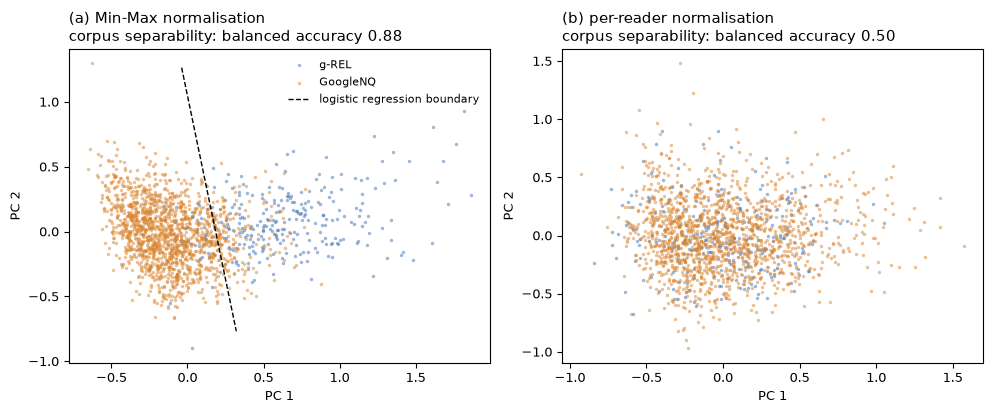

In [19]:
pca = A.pca_separability(grel, nq)
print("corpus separability (BA):", {k: round(v["BA"], 2) for k, v in pca.items()})
figures.pca(pca, RESULTS / "figures" / "figure9_pca.pdf");

## 9. Generalisation to unseen documents (Figure 6, Table S7)

All readers read the same 12 g-REL documents, and in g-REL Agree the label is fixed per document. A model could
therefore score well by recognising *which document* was read instead of *how* it was read. Three splits test
this:
- **participant**: the usual 5 participant folds (new readers of known documents);
- **document**: 4 folds of held-out documents (3 per fold for All, 2 for Agree);
- **both**: new readers *and* new documents.

**How to read it.**
- A model that reads relevance from behaviour keeps its BA across the three columns.
- A model that memorises documents drops when documents are held out. The image-based and hybrid models do drop
  (Section 10).
- Class-balanced models on the per-reader normalised convex hull features keep their performance.

Below the table, a random forest is trained to identify the document from the 17 features, for held-out readers.

In [20]:
unseen = save(A.unseen_documents(grel), "table_S7_unseen_documents_features")
display(unseen)
doc_id = A.document_identification(grel)
print(f"The 17 features identify the g-REL document of held-out readers in {doc_id['accuracy']:.1%} of trials "
      f"(chance {doc_id['chance']:.1%}, {doc_id['documents']} documents).")

,subset,model,BA_participant,BA_document,BA_both
0,All,"LDA, 17 features",0.611,0.590,0.561
1,All,"LDA, 2 convex hull features",0.536,0.500,0.520
2,All,"LDA, 2 convex hull features, per-reader",0.569,0.537,0.549
3,All,"balanced LR (C=0.1), 2 convex hull features, p...",0.605,0.594,0.597
4,All,"balanced NB, 2 convex hull features, per-reader",0.584,0.561,0.568
5,Agree,"LDA, 17 features",0.668,0.546,0.567
6,Agree,"LDA, 2 convex hull features",0.672,0.543,0.531
7,Agree,"LDA, 2 convex hull features, per-reader",0.721,0.602,0.601
8,Agree,"balanced LR (C=0.1), 2 convex hull features, p...",0.711,0.718,0.723
9,Agree,"balanced NB, 2 convex hull features, per-reader",0.690,0.718,0.747


The 17 features identify the g-REL document of held-out readers in 14.9% of trials (chance 8.3%, 12 documents).


## 10. Neural models and statistical tests (optional inputs)

The image-based and hybrid models (VGG19, ViT, VTNet) need a GPU. This repository re-implements the analyses of
VTNet and VGG19 in `scripts/run_neural_models.py`, with fixed hyperparameters so that all splits are comparable:
- unseen documents;
- document identification from images;
- the VTNet branch ablation, with per-trial predictions.

The script renders the heatmaps, scanpaths and time series from the raw data with the paper's code
(`src/gaze_relevance/representations.py`). That code is adapted from `DataGeneration/CNN_Data_Generation.ipynb` of the
[GNN-Scanpath-Analysis-ICMI2024](https://github.com/DFKI-Interactive-Machine-Learning/GNN-Scanpath-Analysis-ICMI2024)
repository:

```bash
pip install -r requirements-gpu.txt
CUDA_VISIBLE_DEVICES=0 python scripts/run_neural_models.py all     # several GPU hours
```

Its outputs land in `results/gpu/` and are shown below. Without them, these cells only print a message.

In [21]:
GPU = RESULTS / "gpu"
for f in ["vtnet_unseen_documents.csv", "vgg19_unseen_documents.csv"]:
    if (GPU / f).exists():
        print(f); display(pd.read_csv(GPU / f))
    else:
        print(f"{f}: not available - run `python scripts/run_neural_models.py` on a GPU machine")

vtnet_unseen_documents.csv: not available - run `python scripts/run_neural_models.py` on a GPU machine
vgg19_unseen_documents.csv: not available - run `python scripts/run_neural_models.py` on a GPU machine


### 10.1 Per-reader tests: VTNet ablation and VTNet vs LDA

With only five folds, fold-level tests have little power. When every trial has a prediction, models can be compared
**per reader** (24 paired units, Wilcoxon signed-rank test, Holm adjustment). The predictions are the full VTNet,
its CNN branch alone and its GRU branch alone (scanpaths, three seeds, averaged). LDA on the 17 features is added
on the same participant folds.

**How to read it.** `a_better`, `b_better` and `equal` count readers. A Holm-adjusted `p_Holm` < 0.05 indicates a
difference that holds across readers.

In [22]:
abl_file = Path(os.environ.get("ABLATION_PREDICTIONS", GPU / "vtnet_ablation_predictions.csv"))
if abl_file.exists():
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from gaze_relevance.models import minmax_pipeline
    pr = pd.read_csv(abl_file).rename(columns={"label": "y", "stimulus": "document"})
    wides = []
    for sub in ["All", "Agree"]:
        w = pr[pr.subset == sub].groupby(["user_id", "document", "y", "model"]).prob.mean().unstack("model").reset_index()
        for m in ["full", "cnn_only", "gru_only"]:
            w[m] = (w[m] >= 0.5).astype(int)
        G = grel_subsets(grel)[sub].reset_index(drop=True); p = np.zeros(len(G), int)
        for tr, te in participant_folds(G):
            p[te] = minmax_pipeline(LinearDiscriminantAnalysis).fit(G.iloc[tr][F17], G.y[tr]).predict(G.iloc[te][F17])
        wides.append(w.merge(G.assign(lda=p)[["user_id", "document", "lda"]], on=["user_id", "document"]).assign(subset=sub))
    wide = pd.concat(wides)
    pairs = [(s, a, b) for s in ["All", "Agree"] for a, b in [("full", "cnn_only"), ("full", "gru_only"), ("cnn_only", "gru_only"), ("full", "lda")]]
    reader_tests = save(A.reader_level_tests(wide, pairs), "reader_level_tests_vtnet")
    display(reader_tests)
else:
    print(f"{abl_file.name}: not available - run `python scripts/run_neural_models.py vtnet-ablation` (GPU)")

vtnet_ablation_predictions.csv: not available - run `python scripts/run_neural_models.py vtnet-ablation` (GPU)


### 10.2 Fold-level comparisons with the corrected resampled t-test

The paper compares models on their five fold scores. Training sets of different folds overlap, so a plain paired
t-test is too optimistic. We use the **corrected resampled t-test** of Nadeau & Bengio (2003), which inflates the
variance by the factor (1/k + n_test/n_train), and the **Holm adjustment** over the 13 comparisons.

The test needs the fold-level balanced accuracies of the neural models from the original training runs. Set
`ORIGINAL_RESULTS` to a folder with `<model>/gREL_<subset>.csv` files, each containing a `Balanced Accuracy`
column whose first five rows are the folds. The feature-based folds come from Section 5.

In [23]:
ORIG = os.environ.get("ORIGINAL_RESULTS")
FILES = {"VTNet-scanpath": "Scanpath_VTNet", "VTNet-heatmap": "Heatmaps_VTNet", "ViT-scanpath": "Scanpath_Transformer",
         "ViT-heatmap": "Heatmaps_Transformer", "VGG19-scanpath": "Scanpath_VGG19", "VGG19-heatmap": "Heatmaps_VGG19",
         "TabPFN": "TabPFN", "VTNet CNN-branch only": "VTNet_CNN/Scanpath_VTNet"}
COMPARISONS = [("All", "VTNet-scanpath", "TabPFN"), ("Agree", "VTNet-heatmap", "TabPFN"),
               ("All", "VTNet-scanpath", "VTNet CNN-branch only"), ("All", "ViT-scanpath", "ViT-heatmap"),
               ("All", "VGG19-heatmap", "VGG19-scanpath"), ("Agree", "ViT-heatmap", "ViT-scanpath"),
               ("Agree", "VGG19-heatmap", "VGG19-scanpath"), ("All", "VTNet-scanpath", "VTNet-heatmap"),
               ("Agree", "VTNet-heatmap", "VTNet-scanpath"), ("All", "TabPFN", "Features (nested)"),
               ("Agree", "TabPFN", "Features (nested)"), ("All", "VTNet-scanpath", "ViT-scanpath"),
               ("Agree", "VTNet-heatmap", "VGG19-heatmap")]
if ORIG and Path(ORIG).exists():
    fold_ba = {}
    for sub, a, b in COMPARISONS:
        for m in (a, b):
            fold_ba[(sub, m)] = (nested_folds[(nested_folds.corpus == "g-REL") & (nested_folds.subset == sub)].BA.values
                                 if m == "Features (nested)" else
                                 pd.read_csv(Path(ORIG) / FILES[m] / f"gREL_{sub}.csv")["Balanced Accuracy"].values[:5].astype(float))
    fold_tests = save(A.fold_level_tests(fold_ba, COMPARISONS), "fold_level_tests")
    display(fold_tests[["subset", "A", "B", "mean_A", "mean_B", "diff", "CI_low", "CI_high", "p_naive", "p_corrected", "p_corrected_Holm"]])
    print(f"significant after correction and Holm adjustment: {int((fold_tests.p_corrected_Holm < 0.05).sum())} of {len(fold_tests)}")
else:
    print("ORIGINAL_RESULTS not set - fold-level comparisons of the neural models skipped")

ORIGINAL_RESULTS not set - fold-level comparisons of the neural models skipped


## 11. Summary

The key numbers of this run in one table, also saved as `results/summary.csv`.

In [24]:
def get(df, **kw):
    m = np.ones(len(df), bool)
    for k, v in kw.items():
        m &= (df[k] == v).values
    return df[m].iloc[0]

T = lambda cfg, tgt: get(table_s5, configuration=cfg, target=tgt)
summary = pd.DataFrame([
    ("g-REL, nested feature models", "All / Agree / Topical", " / ".join(f"{get(nested, corpus='g-REL', subset=s).BA_mean:.3f}" for s in ["All", "Agree", "Topical"])),
    ("GoogleNQ, nested feature models", "All / Agree", " / ".join(f"{get(nested, corpus='GoogleNQ', subset=s).BA_mean:.3f}" for s in ["All", "Agree"])),
    ("GoogleNQ, class-weighted SVM + per-reader", "All / Agree", " / ".join(f"{get(vs_within, transfer='convex hull LDA', target=t).within_BA:.3f}" for t in ["GoogleNQ All", "GoogleNQ Agree"])),
    ("visit filter: removed irrelevant vs relevant (All)", "%", f"{get(table_s1, subset='All', threshold_s=3).excluded_irrelevant_pct:.1f} vs {get(table_s1, subset='All', threshold_s=3).excluded_relevant_pct:.1f}"),
    ("dwell time only: all paragraphs vs > 3 s", "BA", f"{get(dwell, subset='All').all_paragraphs_BA:.3f} vs {get(dwell, subset='All').visits_over_3s_BA:.3f}"),
    ("transfer, baseline LDA without per-reader normalisation", "All / Agree", " / ".join(f"{T('baseline (LDA, g-REL All, Min-Max)', t).BA:.3f}" for t in ["GoogleNQ All", "GoogleNQ Agree"])),
    ("transfer, configuration selected on g-REL", "All / Agree", " / ".join(f"{T('selected on g-REL', t).BA:.3f}" for t in ["GoogleNQ All", "GoogleNQ Agree"])),
    ("transfer, convex hull LDA", "All / Agree", " / ".join(f"{T('convex hull LDA (hypothesis-driven)', t).BA:.3f} [{T('convex hull LDA (hypothesis-driven)', t).CI_low:.3f}, {T('convex hull LDA (hypothesis-driven)', t).CI_high:.3f}]" for t in ["GoogleNQ All", "GoogleNQ Agree"])),
    ("convex hull LDA vs within-GoogleNQ SVM, Wilcoxon p", "All / Agree", " / ".join(f"{get(vs_within, transfer='convex hull LDA', target=t).wilcoxon_p:.2f}" for t in ["GoogleNQ All", "GoogleNQ Agree"])),
    ("PCA corpus separability", "Min-Max / per-reader", f"{pca['Min-Max']['BA']:.2f} / {pca['per-reader']['BA']:.2f}"),
], columns=["result", "unit / subsets", "value"])
display(save(summary, "summary"))

,result,unit / subsets,value
0,"g-REL, nested feature models",All / Agree / Topical,0.605 / 0.670 / 0.473
1,"GoogleNQ, nested feature models",All / Agree,0.564 / 0.554
2,"GoogleNQ, class-weighted SVM + per-reader",All / Agree,0.624 / 0.615
3,visit filter: removed irrelevant vs relevant (...,%,12.9 vs 3.8
4,dwell time only: all paragraphs vs > 3 s,BA,0.596 vs 0.579
5,"transfer, baseline LDA without per-reader norm...",All / Agree,0.517 / 0.517
6,"transfer, configuration selected on g-REL",All / Agree,0.580 / 0.580
7,"transfer, convex hull LDA",All / Agree,"0.609 [0.581, 0.639] / 0.623 [0.600, 0.647]"
8,"convex hull LDA vs within-GoogleNQ SVM, Wilcox...",All / Agree,0.26 / 0.86
9,PCA corpus separability,Min-Max / per-reader,0.88 / 0.50


**In short.**
- Gaze features predict perceived relevance for short documents.
- For long documents, all models stay near chance unless the features are normalised per reader.
- With per-reader normalisation, a feature-based model trained on short documents transfers to long ones,
  mainly through the two convex hull features, i.e. denser and slower reading of relevant text.
- The transfer performs comparably to, but not better than, models trained on long documents.
- Image-based and hybrid models lose most of their performance on documents not seen during training.

The software versions of this run are written to `results/environment.json`.

In [25]:
import platform, importlib
info = {"python": platform.python_version(), **{m: importlib.import_module(m).__version__
        for m in ["numpy", "pandas", "scipy", "sklearn", "statsmodels", "matplotlib"]}}
try:
    import shap; info["shap"] = shap.__version__
except ImportError:
    pass
(RESULTS / "environment.json").write_text(json.dumps(info, indent=1)); info

{'python': '3.13.4',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'scipy': '1.18.1',
 'sklearn': '1.9.1',
 'statsmodels': '0.15.0',
 'matplotlib': '3.11.2',
 'shap': '0.52.0'}